In [29]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [30]:
class Task(BaseModel):
    id: str
    title: str
    brief: str = Field(..., description="What to cover")

In [31]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [32]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [33]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [34]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [35]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [ ]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n" 
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [37]:
# Now the reducer section to attach all the sections together
from pathlib import Path
import re

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    final_md = f"# {title}\n\n{body}\n"

    safe_name = re.sub(r'[^a-zA-Z0-9_-]+', '_', title.lower()).strip('_')
    output_path = Path(f"{safe_name}.md")
    output_path.write_text(final_md, encoding="utf-8")

    print(f"Saved markdown file at: {output_path.resolve()}")
    return {"final": final_md}

In [38]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

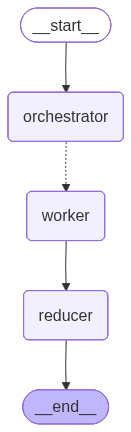

In [39]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [40]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method N

Saved markdown file at: C:\Users\Sanjog Bhalla\Desktop\Langgraph - CampusX\Blog Agent\demystifying_self-attention_the_heart_of_modern_neural_networks.md


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [41]:
print(out["sections"])

['## Introduction to Self-Attention\n\nSelf-attention is a powerful mechanism within neural networks that allows models to weigh the significance of different parts of the input data relative to each other. Originally popularized by the Transformer architecture introduced in the seminal paper *“Attention Is All You Need”* (Vaswani et al., 2017), self-attention has revolutionized the way deep learning models process sequential data.\n\nAt its core, self-attention helps a model to focus on relevant pieces of information when interpreting or generating data. Unlike traditional recurrent models that process input sequentially, self-attention enables parallel processing by dynamically computing relationships between all elements in a sequence. This capability is instrumental in capturing long-range dependencies and contextual nuances.\n\nIn natural language processing (NLP), where understanding the relationship between words over varying distances is crucial, self-attention has become the h